In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from xhistogram.xarray import histogram as xhist
import pandas as pd

In [2]:
ds_FTLE = xr.open_dataset("010_FTLE.nc")
ds_FTLE

<xarray.Dataset> Size: 800kB
Dimensions:  (pos: 40000)
Coordinates:
    lon      (pos) float64 320kB ...
    lat      (pos) float64 320kB ...
Dimensions without coordinates: pos
Data variables:
    FTLE     (pos) float32 160kB ...

In [3]:
df = (ds_FTLE*24*3600).to_dataframe().reset_index()
df

,pos,lon,lat,FTLE
0,0,-29.0,14.000000,0.095402
1,1,-29.0,14.027638,0.115846
2,2,-29.0,14.055276,0.136071
3,3,-29.0,14.082915,0.148541
4,4,-29.0,14.110553,0.152745
...,...,...,...,...
39995,39995,-22.5,19.389447,0.022007
39996,39996,-22.5,19.417085,0.010232
39997,39997,-22.5,19.444724,0.005949
39998,39998,-22.5,19.472362,0.003241


In [10]:
ds_heatmap = xr.open_dataset("012_heatmaps.nc")
ds_heatmap

<xarray.Dataset> Size: 37MB
Dimensions:            (obs: 240, lon: 157, lat: 123)
Coordinates:
  * obs                (obs) int32 960B 0 1 2 3 4 5 ... 234 235 236 237 238 239
  * lon                (lon) float64 1kB -26.39 -26.38 -26.37 ... -24.84 -24.83
  * lat                (lat) float64 984B 16.68 16.69 16.7 ... 17.88 17.89 17.9
Data variables:
    histogram_lon_lat  (obs, lon, lat) int64 37MB ...

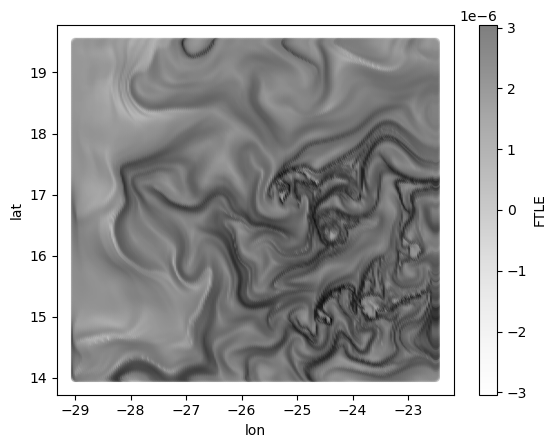

In [32]:
ds_FTLE.plot.scatter(x = "lon", y ="lat", hue = "FTLE", cmap = "Grays", edgecolor = "none", alpha = 0.5)
plt.show()

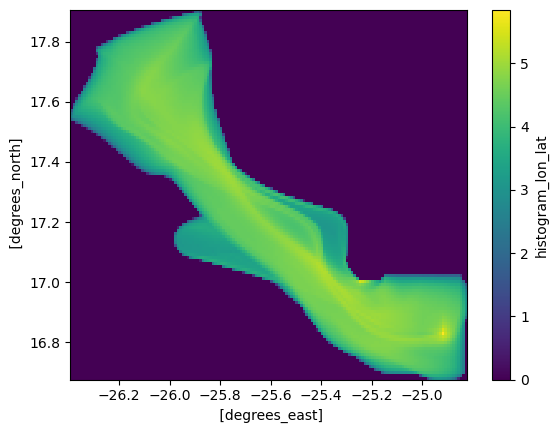

In [12]:
np.log10(ds_heatmap.histogram_lon_lat.sum("obs")+1).fillna(0).plot(x = "lon", y = "lat")
plt.show()

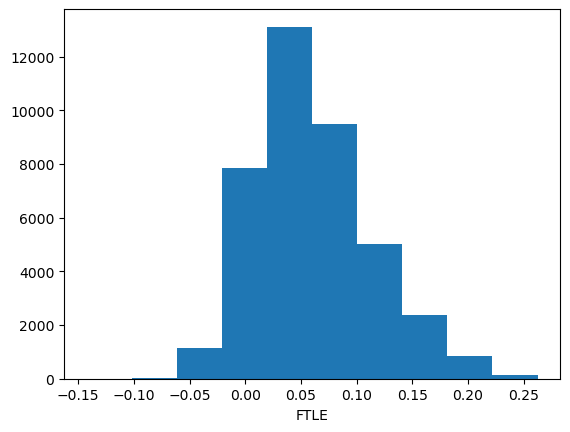

In [14]:
(ds_FTLE.FTLE*24*3600).plot.hist()
plt.show()

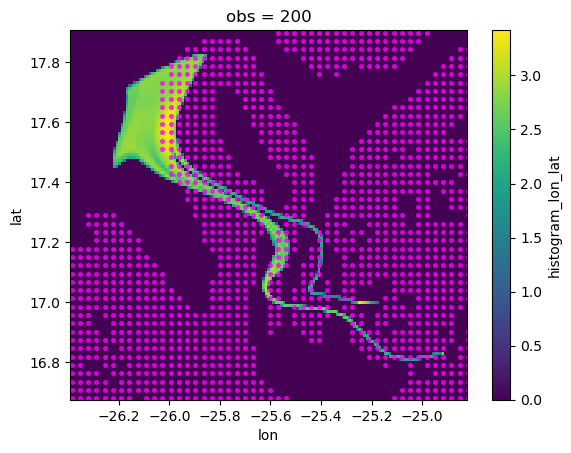

In [34]:
np.log10(ds_heatmap.histogram_lon_lat.sel(obs = 200)+1).fillna(0).plot(x = "lon", y = "lat")
df.where(df.FTLE>0.06).plot.scatter(x = "lon", y = "lat", color = "magenta", s = 7, alpha = 0.7, ax = plt.gca())
plt.show()

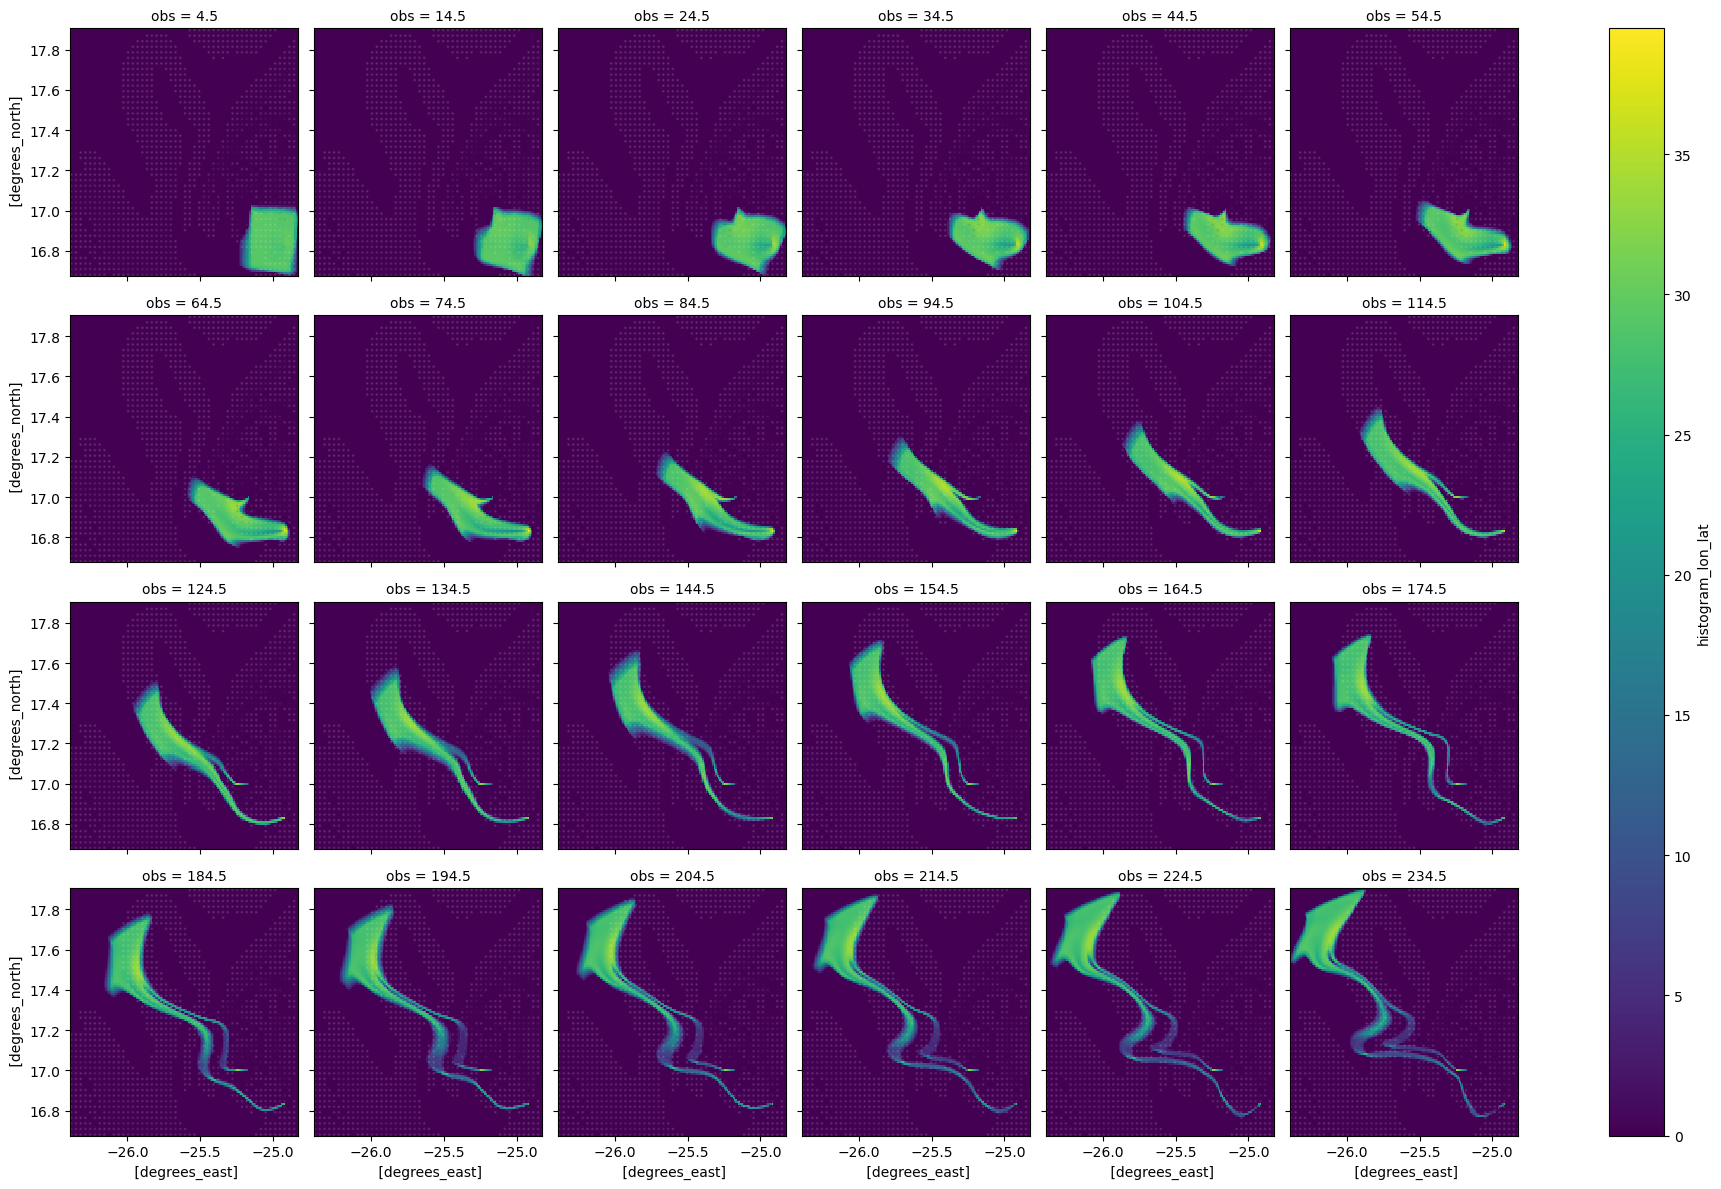

In [31]:
g = np.log10(ds_heatmap.histogram_lon_lat.pad(obs=(0, 1))+1).coarsen(obs=10, boundary="trim").sum().plot(
    col="obs", col_wrap=6, x="lon", y="lat")

g.map(lambda: plt.scatter(df.loc[df.FTLE > 0.06, "lon"], df.loc[df.FTLE > 0.06, "lat"], c=df.loc[df.FTLE > 0.06, "FTLE"], 
                          cmap="Greys", s=1, alpha=0.1))